In [9]:
#web scraping flipkart product reviews using selenium and beautifulsoup
from bs4 import BeautifulSoup
import pandas as pd
import requests
import time
import re
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By

driver = webdriver.Chrome()

product_data = []

for page_no in range(1, 40):
    url = f"https://www.flipkart.com/apple-iphone-16-white-128-gb/product-reviews/itm7c0281cd247be?pid=MOBH4DQF849HCG6G&lid=LSTMOBH4DQF849HCG6GXHBPXY&marketplace=FLIPKART&page={page_no}"
    driver.get(url)
    data = driver.page_source


    soup = BeautifulSoup(data, "html.parser")
    review_text_nodes = soup.select("span.css-1qaijid")
    seen_on_page = set()

    for review_text_html in review_text_nodes:
        elem = review_text_html.find_parent(
            "div",
            style=lambda value: value and 'padding-left:16px' in value and 'padding-top:16px' in value and 'padding-bottom:16px' in value
        )
        if not elem:
            continue

        reviewer_name_html = elem.select_one("div[style*='flex-direction:row;width:100%'] > div.css-1rynq56[dir='auto']")

        review_rating = None
        for rating_node in elem.select("div.css-1rynq56"):
            rating_text = rating_node.get_text(strip=True)
            if re.fullmatch(r"\d+(\.\d+)?", rating_text):
                review_rating = rating_text
                break

        review_text = review_text_html.get_text(strip=True)
        reviewer_name = reviewer_name_html.get_text(strip=True) if reviewer_name_html else None
        unique_key = (reviewer_name, review_rating, review_text)
        if unique_key in seen_on_page:
            continue
        seen_on_page.add(unique_key)

        product_data.append({
            "reviewer_name": reviewer_name,
            "review_rating": review_rating,
            "review_text": review_text
        })

    time.sleep(5)

df = pd.DataFrame(product_data).drop_duplicates(subset=["reviewer_name", "review_rating", "review_text"])
df.to_csv("product_data.csv", index=False)
df


,reviewer_name,review_rating,review_text
0,Taksh Kirar,5.0,Such an great experience
1,Raj Vishwakarma,5.0,Nice ones
2,Flipkart Customer,5.0,Super and cool photo
3,Amit Kumar Chaudhary,5.0,Satisfied
4,Pranesha Mahajan,5.0,Great phone
...,...,...,...
170,Praveen Gowda,4.0,Awesome
171,Sadik Ali,5.0,Veri rugged phone
172,Arijit Das Adhikary,5.0,Good quality
173,Arun teddy,5.0,Good 😊


In [5]:
# Convert review_rating to numeric, coercing errors to NaN
df["review_rating"] = pd.to_numeric(df["review_rating"], errors="coerce")

In [3]:
# drop duplicates based on reviewer_name, review_rating, and review_text
df.drop_duplicates(subset=["reviewer_name"], inplace=True)

In [4]:
# Check for missing values
df.isna().sum()

reviewer_name    0
review_rating    0
review_text      0
dtype: int64

In [6]:
# processing the review_text column for sentiment analysis and other NLP tasks
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
import string

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


text=df["review_text"]
def clean_text(text):
    # lowercase
    text = text.lower()
    
    # remove punctuation & special characters
    text = re.sub(r"[^\w\s]", "", text)
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # tokenize
    words = word_tokenize(text)
    
    # remove stopwords
    words = [w for w in words if w not in stop_words]
    
    # lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return " ".join(words)

# Apply to dataframe column
df["clean_review"] = df["review_text"].apply(clean_text)

df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\choud\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\choud\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\choud\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\choud\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\choud\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,reviewer_name,review_rating,review_text,clean_review
0,Taksh Kirar,5.0,Such an great experience,great experience
1,Raj Vishwakarma,5.0,Nice ones,nice one
2,Flipkart Customer,5.0,Super and cool photo,super cool photo
3,Amit Kumar Chaudhary,5.0,Satisfied,satisfied
4,Pranesha Mahajan,5.0,Great phone,great phone


In [7]:
# Perform sentiment analysis using TextBlob
t=df["clean_review"]
def sentiment_analysis(t):
    blob = TextBlob(t)
    if blob.polarity >=0.1:
        return "positive"
    else:
        return "Negative"
df["sentiment"] = df["clean_review"].apply(sentiment_analysis)


C:\Users\choud\AppData\Local\Temp\ipykernel_19348\2088320641.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["sentiment"].value_counts().index, y=df["sentiment"].value_counts().values, palette="Set2")


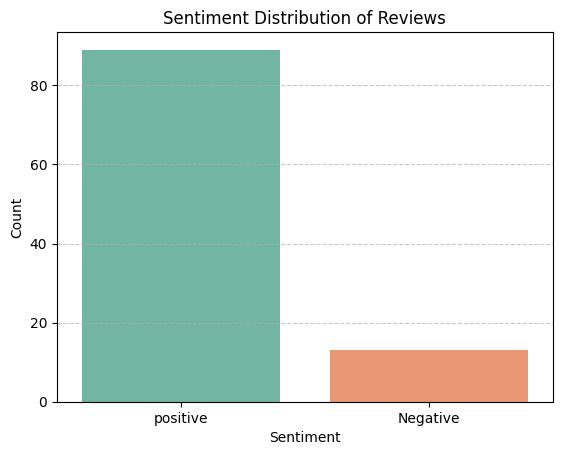

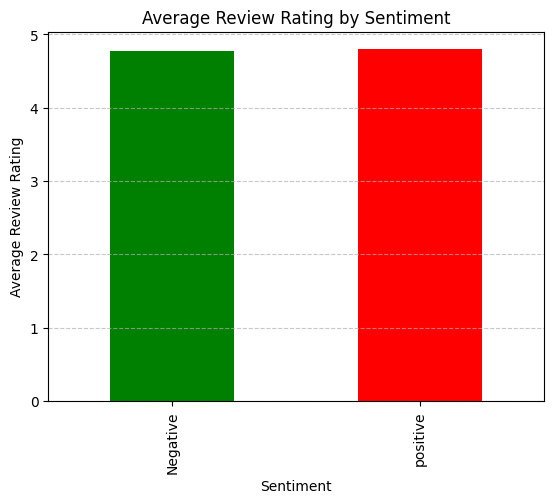

C:\Users\choud\AppData\Local\Temp\ipykernel_19348\2088320641.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sentiment", y="review_length", data=df, palette="Set2")


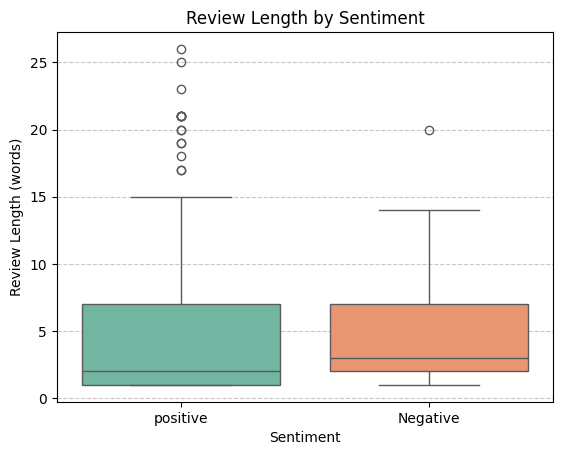

In [8]:
# Visualize sentiment distribution
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Set the style of the plot
sns.barplot(x=df["sentiment"].value_counts().index, y=df["sentiment"].value_counts().values, palette="Set2")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution of Reviews")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


# Visualize average review rating by sentiment
df.groupby("sentiment")["review_rating"].mean().plot(kind="bar", color=["green", "red"])
plt.xlabel("Sentiment")
plt.ylabel("Average Review Rating")
plt.title("Average Review Rating by Sentiment")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
df["review_length"]=df["clean_review"].str.split().apply(len)

#Check if longer reviews correlate with sentiment.
sns.boxplot(x="sentiment", y="review_length", data=df, palette="Set2")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.title("Review Length by Sentiment")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
